In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
#from sklearn.metrics import mean_squared_error, r2_score
#from sklearn.linear_model import LinearRegression
#from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
#from sklearn.svm import SVR
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense,LSTM

In [2]:
df=pd.read_csv('/kaggle/input/datasets/amarjithsinghk/gold-price1833-2026/monthly.csv')
df.head()

,Date,Price
0,1833-01,18.93
1,1833-02,18.93
2,1833-03,18.93
3,1833-04,18.93
4,1833-05,18.93


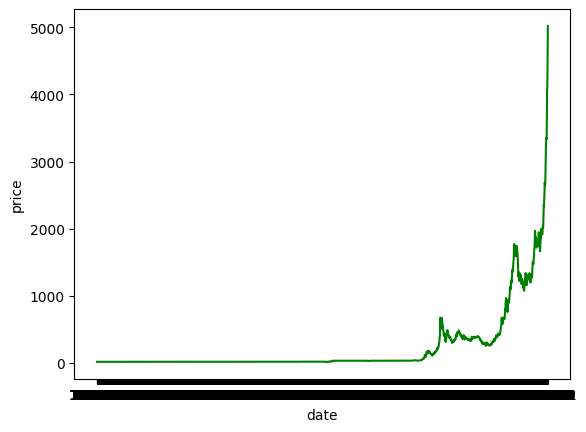

In [3]:
import matplotlib.dates as mdates

plt.xlabel("date")
plt.ylabel("price")
plt.plot(df.Date,df.Price,color='green')

In [4]:
df['year'] = pd.to_datetime(df['Date']).dt.year
df['month'] = pd.to_datetime(df['Date']).dt.month

display(df.head())

,Date,Price,year,month
0,1833-01,18.93,1833,1
1,1833-02,18.93,1833,2
2,1833-03,18.93,1833,3
3,1833-04,18.93,1833,4
4,1833-05,18.93,1833,5


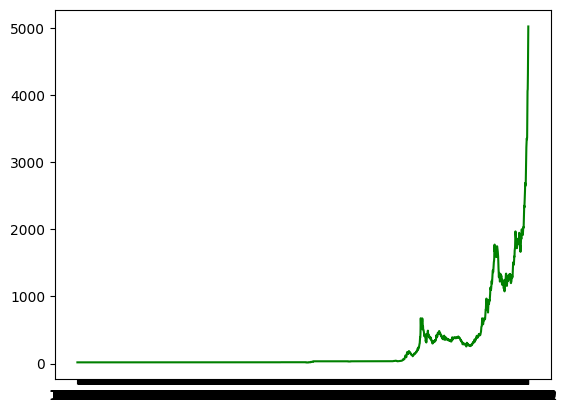

In [5]:
plt.plot(df.Date,df.Price,color='green')

In [6]:
X = df[['year', 'month']]
Y = df['Price']

# Split the data into training and testing sets
X_t, X_te, Y_t, Y_te = train_test_split(X, Y, test_size=0.25, random_state=0)


In [7]:
#model=LinearRegression()
#model = RandomForestRegressor(n_estimators=5, random_state=0)
model=XGBRegressor(n_estimators=1000, learning_rate=0.05)
model.fit(X_t, Y_t)

# Make predictions on the test set
y_pred = model.predict(X_te)
print("Predictions on test set:")
print(y_pred)

Predictions on test set:
[1494.7257     18.9322     18.952028   33.85143    18.945057   35.11188
   20.625353   35.09058  1725.7437    814.3104     18.93057    33.85143
   20.680183  438.94556    18.93806    18.943514   18.93806    18.990948
   18.935854   18.92526    20.717442  423.34332    18.932896  432.37158
   35.28872   380.36835    34.932877   18.956545   18.92526    33.79578
   18.950129   34.6718     18.938398   18.933908   18.940928   18.951273
   33.972897   34.822536 1150.0352     18.92711    18.92984    18.931353
  300.29565  3329.307     457.98883   413.09613  3305.514      18.959812
   18.942282   18.985804   18.926655   18.942282   20.569242   20.642046
   20.46727    18.924229   18.932241 1276.3705     20.76583    18.968643
   18.99667    18.937298   18.96947    18.94955  1252.0197     18.937073
  128.96939  1359.6421   1260.7023   1257.3911     18.939117 3365.576
  287.59155    20.529432   18.94664    33.941498   18.959547  265.1377
   18.938627   18.932514   34.90604

In [8]:
import numpy as np
target_year = 2037
target_month = 7
prediction_input = np.array([[target_year, target_month]])
y_pr = model.predict(prediction_input)
print(f"Predicted price for {target_year}-{target_month}: {y_pr[0]:.2f} USD")

Predicted price for 2037-7: 4746.82 USD
